# **Part 5:** Calibration Statistics

**Authors:** Isabella Pedraza, Jack Logan <br>
**Last Updated:** May 7, 2025

### Agenda:
- Plot 1:1 of results
- Explore model fit statistics
- Visualize Posterior Distributions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyemu

import glob

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error as mse
from scipy.stats import pearsonr, norm

# Plot 1:1 of IES Results

## Read in Residuals

When we run the model on HPC, we download the outputs of IES in a zip file. We then unzip this file with the name `ies/` in the main directory. Now we will read in the residual files from each ies iteration. These are files ending in `.rei`. 

In [2]:
# Get all residual file paths
rei_files = glob.glob('../ies/peterson_tran.*.base.rei')

After getting the list of files using glob, we can read them into a pandas dataframe. We have to skip the first row because there is a header, but the rest is whitespace delimeted which can be read in using `sep='\s+'`.

In [3]:
# Read all residual files, append to list
rei_list = []
for i, file in enumerate(rei_files):
    data = pd.read_csv(file, sep=r'\s+', skiprows=1)
    data['iteration'] = i + 1
    rei_list.append(data)

rei_df = pd.concat(rei_list)  # concat to one df

## Get Last Iteration + Categories

In theory, the final iteration is the best iteration. We well gather only the data from that iteration here, then scale the concentrations from $\frac{mg}{L}$ to $\frac{ng}{L}$. After that, we will get the solute groups and map them to colors for plotting purposes.

In [4]:
rei_last = rei_df[rei_df['iteration'] == rei_df['iteration'].max()]
rei_last = rei_last.copy()

rei_last.loc[:, 'Measured'] *= 1e6
rei_last.loc[:, 'Modelled'] *= 1e6

In [5]:
# Add a new column to assign colors based on the observation name
def get_category(name):
    if '_pfos' in name:
        return 'PFOS'
    elif '_pfoa' in name:
        return 'PFOA'
    elif '_pfhxs' in name:
        return 'PFHxS'
    else:
        return 'Other'  # Default category if name doesn't match

# category based colormap
cmap = {'PFOS':'steelblue', 'PFOA':'tomato', 'PFHxS':'forestgreen', 'Other':'grey'}

# map categories as column of DF
rei_last['category'] = rei_last['Name'].apply(get_category)

## All PFAS, One Plot

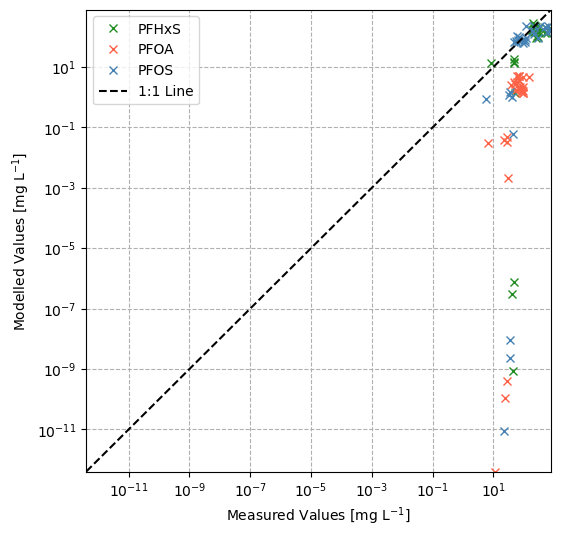

In [6]:
# Create the log-log plot with manually set colors
plt.figure(figsize=(6,6))

for label in np.unique(rei_last['category']):
    label_df = rei_last[rei_last['category']==label]
    plt.loglog(
        label_df['Measured'], 
        label_df['Modelled'], 
        c=cmap[label],
        ls='', marker='x',
        label=label
    )

# Set equal axis limits (same limits for both axes)
min_val = min(rei_last["Measured"].min(), rei_last["Modelled"].min())
max_val = max(rei_last["Measured"].max(), rei_last["Modelled"].max())

# Add a 1:1 line for reference
plt.plot(
    [min_val, max_val], 
    [min_val, max_val],
    color="black", 
    linestyle="--", 
    label="1:1 Line"
)

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

# Labels and title
plt.xlabel("Measured Values [mg L$^{-1}$]")
plt.ylabel("Modelled Values [mg L$^{-1}$]")

# Format RMSE text for display
# rmse_text = "\n".join([f"{key}{' RMSE [mg/L]'}: {value:.4f}" for key, value in rmse_values.items() if value is not None])

# plt.title(f"Log-Scaled Modeled vs. Measured (Iteration {last_iter})\n{rmse_text}")

plt.legend(loc="upper left")
plt.grid(ls='--')

# Show the plot
plt.show()

## All PFAS, Three Plots

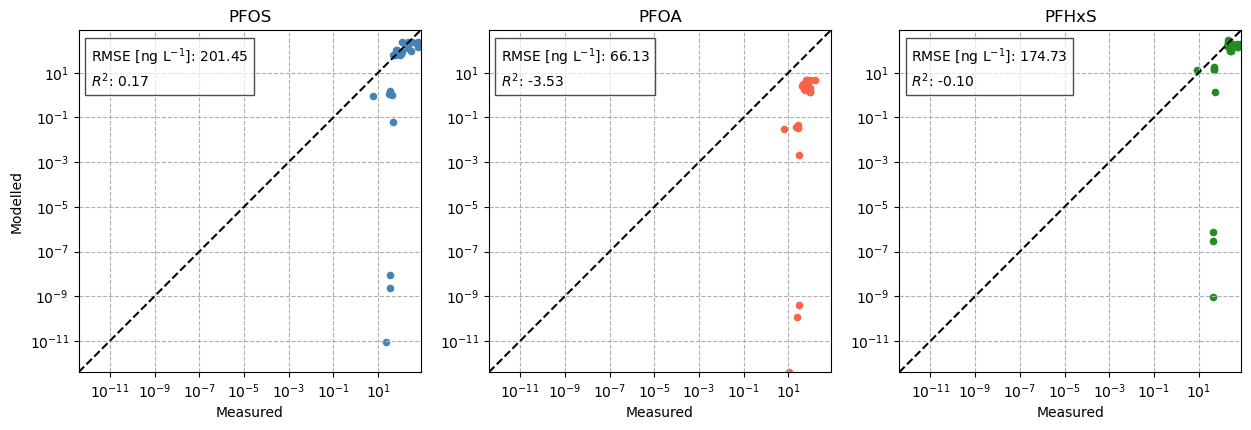

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(15,6))
ax1, ax2, ax3 = axs

min_val = min(rei_last["Measured"].min(), rei_last["Modelled"].min())
max_val = max(rei_last["Measured"].max(), rei_last["Modelled"].max())

for ax, label in zip(axs, cmap.keys()):
    solute = rei_last[rei_last['category']==label]  # get solute

    # plot observed vs simulated with a 1:1 line
    solute.plot.scatter('Measured', 'Modelled', ax=ax, c=cmap[label])
    ax.plot([min_val, max_val], [min_val, max_val], ls='--', c='k')

    ax.set_title(label)
    ax.set_yscale('log')
    ax.set_xscale('log')

    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.grid(ls='--')
    ax.set_aspect('equal')

    rmse = np.sqrt(mse(solute['Measured'], solute['Modelled']))
    r2 = r2_score(solute['Measured'], solute['Modelled'])
    
    ax.text(
        0.035, 0.835, 
        f'RMSE [ng L$^{{-1}}$]: {rmse:.2f}\n$R^2$: {r2:.2f}', 
        transform=ax.transAxes, 
        fontsize=10, 
        bbox=dict(facecolor='white', alpha=0.7)
    )

ax2.set_ylabel(None)
ax3.set_ylabel(None)

plt.show()

# Model Fit Statistics

Using the function `normalized_model_stats()` below, we will evaluate the performance of the model results for each solute.

In [8]:
def normalized_model_stats(obs, model):
    obs = np.array(obs)
    model = np.array(model)

    mae = np.mean(np.abs(obs - model))
    rmse = np.sqrt(np.mean((obs - model)**2))
    nrmse_mean = rmse / (np.mean(obs) )
    nrmse_range = rmse / (np.max(obs) - np.min(obs) )
    pbias = 100 * np.sum(model - obs) / (np.sum(obs) )

    r, _ = pearsonr(obs, model)
    beta = np.mean(model) / (np.mean(obs) )
    gamma = np.std(model) / (np.std(obs) )
    kge = 1 - np.sqrt((r - 1)**2 + (beta - 1)**2 + (gamma - 1)**2)

    d = 1 - np.sum((model - obs)**2) / (np.sum((np.abs(model - np.mean(obs)) + np.abs(obs - np.mean(obs)))**2) )

    nse = 1 - np.sum((obs - model)**2) / (np.sum((obs - np.mean(obs))**2) )
    
    r_squared = r**2  # R^2

    return {
        "RMSE": rmse,
        "nRMSE_m": nrmse_mean,
        "nRMSE_r": nrmse_range,
        "NSE": nse,
        "R^2": r_squared,
        "PBIAS": pbias,
        "KGE": kge,
        "Willmott d": d,
        "Pearson r": r
    }

In [9]:
model_stats = {}
for solute in ['PFOS', 'PFOA', 'PFHxS']:
    solute_data = rei_last[rei_last['category'] == solute]
    model_stats[solute] = normalized_model_stats(solute_data['Measured'], solute_data['Modelled'])

## PFOS Results

In [10]:
print('PFOS Stats:')

for k, v in model_stats['PFOS'].items():
    print(f'\t{k:<12}: {v:.4f}')

PFOS Stats:
	RMSE        : 201.4534
	nRMSE_m     : 1.0533
	nRMSE_r     : 0.2554
	NSE         : 0.1653
	R^2         : 0.4697
	PBIAS       : -50.5204
	KGE         : 0.1188
	Willmott d  : 0.5757
	Pearson r   : 0.6853


## PFOS Results

In [11]:
print('PFOA Stats:')

for k, v in model_stats['PFOA'].items():
    print(f'\t{k:<12}: {v:10.5f}')

PFOA Stats:
	RMSE        :   66.12764
	nRMSE_m     :    1.08513
	nRMSE_r     :    0.46067
	NSE         :   -3.53215
	R^2         :    0.38019
	PBIAS       :  -96.62815
	KGE         :   -0.40681
	Willmott d  :    0.41104
	Pearson r   :    0.61659


## PFHxS Results

In [12]:
print('PFHxS Stats:')

for k, v in model_stats['PFHxS'].items():
    print(f'\t{k:<12}: {v:10.5f}')

PFHxS Stats:
	RMSE        :  174.73207
	nRMSE_m     :    0.74079
	nRMSE_r     :    0.24921
	NSE         :   -0.10016
	R^2         :    0.32782
	PBIAS       :  -45.87366
	KGE         :    0.19456
	Willmott d  :    0.61360
	Pearson r   :    0.57255


# View Posterier Distributions

## Load in Priors and Posteriors

First, we have to load in the prior and posterior distributions. The prior distribution is the distribution at the first iteration (iteration 0), and the posterior is the distribution at the final iteration (iteration 10).

In [13]:
prior = pd.read_csv('../ies/peterson_tran.0.par.csv')  # First iteration
posterior = pd.read_csv('../ies/peterson_tran.10.par.csv')  # Final distribution

Now we will refine these dataframes for plotting. We don't want any data that corresponds to the immobile domain. These any parameter names that end with the number 1, except `mult1`, which corresponds to the source zone multiplier. We also want to get rid of the `real_name` column, as this will not provide any useful information pre- and post-calibration

In [14]:
# Get column names to drop (anything corresponding to immobile domain)
drop_cols = [col for col in prior.columns if col.endswith('1') and (col != 'mult1')] + ['real_name']

# Drop zone 1 from prior and posterios
prior = prior.drop(columns=drop_cols)
posterior = posterior.drop(columns=drop_cols)

# Get param names and number of total params
params = prior.columns
n_params = len(prior.columns)
n_params

28

This leaves us with 24 PDFs of interest. For plotting purposes, the next cell creates a dictionary mapping each parameter name as it appears in PEST to a more descriptive title and the units of this parameter.

In [15]:
# Param name -> title, units
name_dict = {
    'mult1': {
        'title':'Zone 1 Mass Loading Factor',
        'units':'[-]'
    },
    'mult2': {
        'title': 'Zone 2 Mass Loading Factor',
        'units': '[-]'
    },
    'mult3': {
        'title': 'Zone 3 Mass Loading Factor',
        'units': '[-]'
    },
    'mult4': {
        'title': 'Zone 4 Mass Loading Factor',
        'units': '[-]'
    },
    'theta1': {
        'title': 'Porosity Pierre Shale',
        'units': '[-]'
    },
    'theta2': {
        'title': 'Porosity Eolian Sand and Loess',
        'units': '[-]'
    },
    'theta3': {
        'title': 'Porosity Clay-Dominated',
        'units': '[-]'
    },
    'theta4': {
        'title': 'Porosity Silty Sand',
        'units': '[-]'
    },
    'theta5': {
        'title': 'Porosity Gravel-Dominated',
        'units': '[-]'
    },
    'thetaim1': {
        'title': 'Immobile Porosity Pierre Shale',
        'units': '[-]'
    },
    'thetaim2': {
        'title': 'Immobile Porosity Eolian Sand and Loess',
        'units': '[-]'
    },
    'thetaim3': {
        'title': 'Immobile Porosity Clay-Dominated',
        'units': '[-]'
    },
    'thetaim4': {
        'title': 'Immobile Porosity Silty Sand',
        'units': '[-]'
    },
    'thetaim5': {
        'title': 'Immobile Porosity Gravel-Dominated',
        'units': '[-]'
    },
    'rhob1': {
        'title': 'Bulk Density Pierre Shale',
        'units': '[kg m$^{-3}$]'
    },
    'rhob2': {
        'title': 'Bulk Density Eolian Sand and Loess',
        'units': '[kg m$^{-3}$]'
    },
    'rhob3': {
        'title': 'Bulk Density Clay-Dominated',
        'units': '[kg m$^{-3}$]'
    },
    'rhob4': {
        'title': 'Bulk Density Silty Sand',
        'units': '[kg m$^{-3}$]'
    },
    'rhob5': {
        'title': 'Bulk Density Gravel-Dominated',
        'units': '[kg m$^{-3}$]'
    },
    'pfos_kd1': {
        'title': 'Kd PFOS Pierre Shale',
        'units': '[m$^3$ kg$^{-1}$]'
    },
    'pfos_kd2': {
        'title': 'Kd PFOS Eolian Sand and Loess',
        'units': '[m$^3$ kg$^{-1}$]'
    },
    'pfos_kd3': {
        'title': 'Kd PFOS Clay-Dominated',
        'units': '[m$^3$ kg$^{-1}$]'
    },
    'pfos_kd4': {
        'title': 'Kd PFOS Silty Sand',
        'units': '[m$^3$ kg$^{-1}$]'
    },
    'pfos_kd5': {
        'title': 'Kd PFOS Gravel-Dominated',
        'units': '[m$^3$ kg$^{-1}$]'
    },
    'pfoa_kd1': {
        'title': 'Kd PFOA Pierre Shale',
        'units': '[m$^3$ kg$^{-1}$]'
    },
    'pfoa_kd2': {
        'title': 'Kd PFOA Eolian Sand and Loess',
        'units': '[m$^3$ kg$^{-1}$]'
    },
    'pfoa_kd3': {
        'title': 'Kd PFOA Clay-Dominated',
        'units': '[m$^3$ kg$^{-1}$]'
    },
    'pfoa_kd4': {
        'title': 'Kd PFOA Silty Sand',
        'units': '[m$^3$ kg$^{-1}$]'
    },
    'pfoa_kd5': {
        'title': 'Kd PFOA Gravel-Dominated',
        'units': '[m$^3$ kg$^{-1}$]'
    },
    'pfhxs_kd1': {
        'title': 'Kd PFHXS Pierre Shale',
        'units': '[m$^3$ kg$^{-1}$]'
    },
    'pfhxs_kd2': {
        'title': 'Kd PFHXS Eolian Sand and Loess',
        'units': '[m$^3$ kg$^{-1}$]'
    },
    'pfhxs_kd3': {
        'title': 'Kd PFHXS Clay-Dominated',
        'units': '[m$^3$ kg$^{-1}$]'
    },
    'pfhxs_kd4': {
        'title': 'Kd PFHXS Silty Sand',
        'units': '[m$^3$ kg$^{-1}$]'
    },
    'pfhxs_kd5': {
        'title': 'Kd PFHXS Gravel-Dominated',
        'units': '[m$^3$ kg$^{-1}$]'
    }
}

Okay, now we're ready to plot the distributions. The next cell will plot all 24 on the same plot.

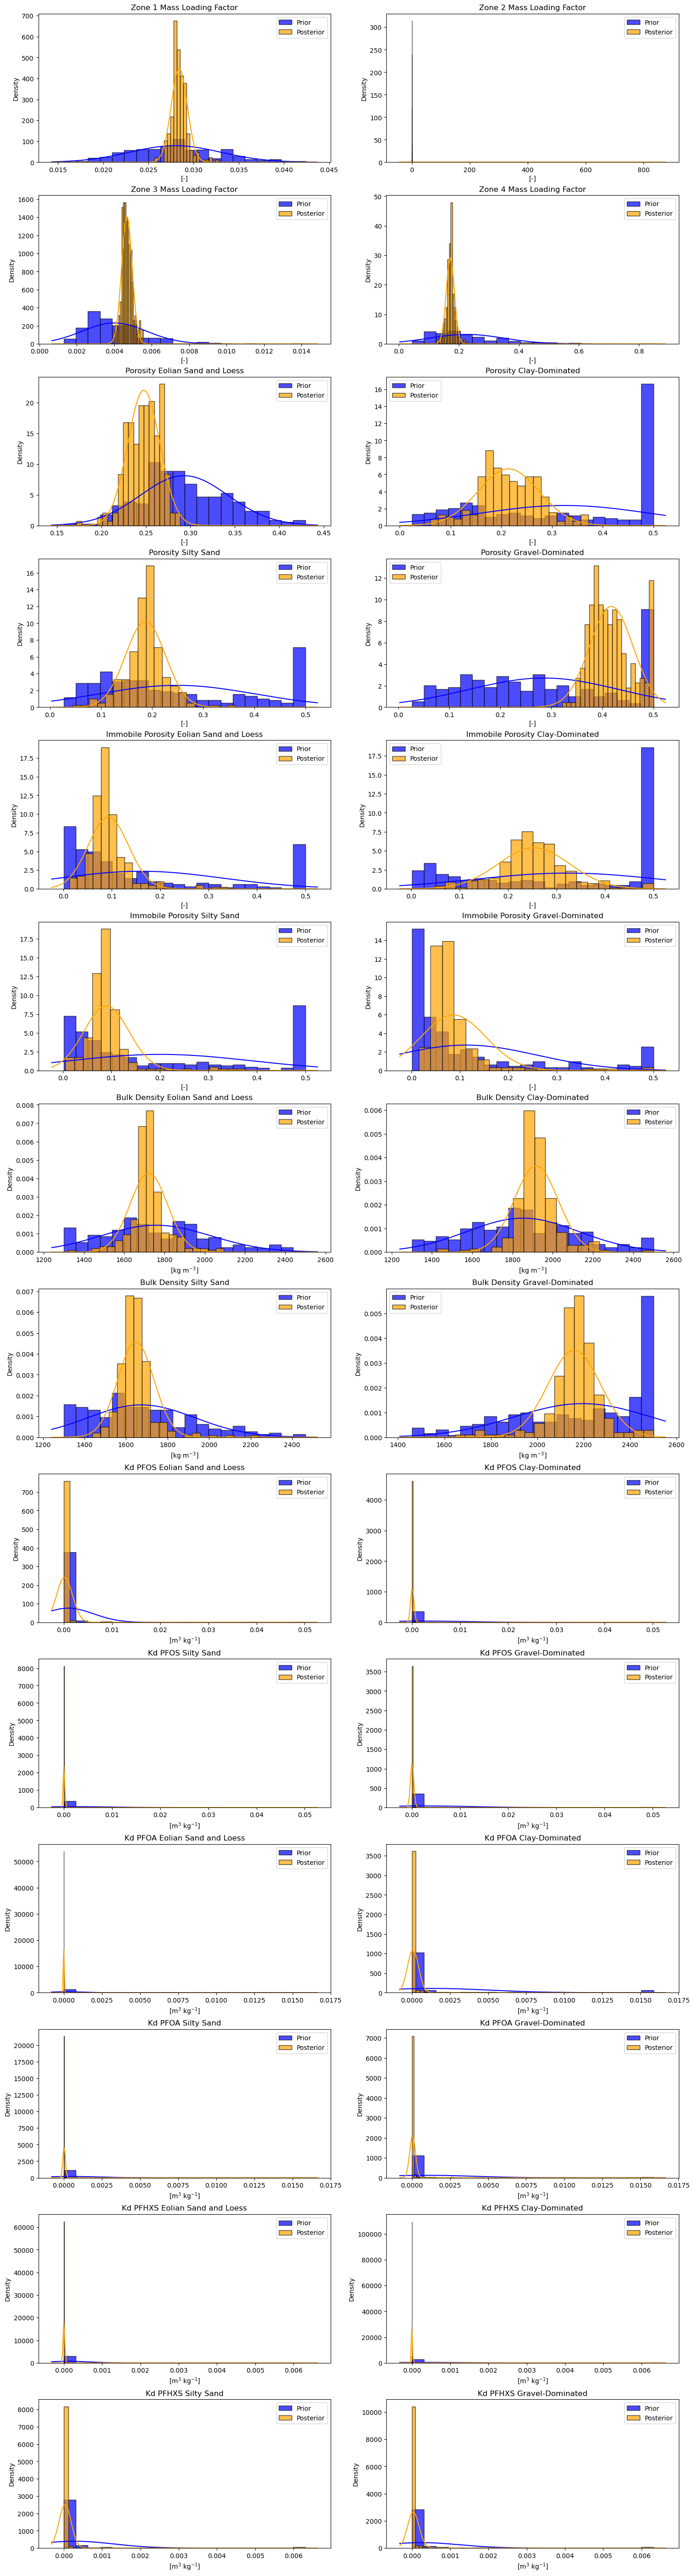

In [16]:
# create a 14 x 2 subplots
fig, axs = plt.subplots(n_params//2, 2, figsize=(15, 2*n_params), layout='constrained')
axs = axs.flatten()  # Flatten the array for iteration

for i, param in enumerate(params):  # Iterate through param names, plot accordingly
    ax = axs[i]

    # Prior distribution histogram
    ax.hist(prior[param], color='blue', label='Prior', bins=20, density=True, ec='k', alpha=0.7)

    # Posterior distribution histogram 
    ax.hist(posterior[param], color='orange', label='Posterior', bins=20, density=True, ec='k', alpha=0.7)

    # generate the PDF line for a smoothed trendline
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 200)
    prior_pdf = norm.pdf(x, np.mean(prior[param]), np.std(prior[param]))
    posterior_pdf = norm.pdf(x, np.mean(posterior[param]), np.std(posterior[param]))

    # Plot the prior and posterior PDF
    ax.plot(x, prior_pdf, c='blue')
    ax.plot(x, posterior_pdf, c='orange')

    # Pretty up the plots
    ax.legend()
    ax.set_title(name_dict[param]['title'])
    ax.set_ylabel('Density')
    ax.set_xlabel(name_dict[param]['units'])